# Working with CATEGORICAL data in Pandas:


Pandas is the defacto toolbox for Python data scientists to ease the data analysis process. You can use it before you start analyzing, to collect, explore, and format the data. Pandas makes these steps a breeze via its numerous I/O and handy data manipulation functions.

**During Data analysis**, you must have encountered non-numeric datatypes mainly dates and some repetitive values called categorical datatypes.

**In this tutorial**, you'll learn the common tricks to handle **'categorical'** type of data and preprocess it to build machine learning models with them.

## Loading Datasets into colab:
Data Source: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents

In [ ]:
# import kagglehub
# from pathlib import Path

# path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
# filepath = Path(path, 'US_Accidents_March23.csv')

# print("Path to dataset:", filepath)

ModuleNotFoundError: No module named 'kagglehub'

In [2]:
# Installing GDown
!pip install gdown -q

# Downloading file
!gdown 1V8SE7NE-NxOoirgmmyuEX5w-sA2Stzxq


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1V8SE7NE-NxOoirgmmyuEX5w-sA2Stzxq
To: g:\ML Course\Week 4\US_Accidents_Jan23-March23.csv

  0%|          | 0.00/103M [00:00<?, ?B/s]
  1%|          | 524k/103M [00:00<00:38, 2.68MB/s]
  1%|          | 1.05M/103M [00:00<00:33, 3.06MB/s]
  3%|▎         | 3.15M/103M [00:00<00:12, 7.91MB/s]
  5%|▍         | 4.72M/103M [00:00<00:10, 9.10MB/s]
  6%|▌         | 6.29M/103M [00:00<00:09, 9.77MB/s]
  8%|▊         | 7.86M/103M [00:00<00:09, 10.2MB/s]
  9%|▉         | 9.44M/103M [00:01<00:08, 10.5MB/s]
 11%|█         | 11.0M/103M [00:01<00:08, 10.7MB/s]
 12%|█▏        | 12.6M/103M [00:01<00:08, 10.8MB/s]
 14%|█▎        | 14.2M/103M [00:01<00:08, 10.9MB/s]
 15%|█▌        | 15.7M/103M [00:01<00:07, 11.0MB/s]
 17%|█▋        | 17.3M/103M [00:01<00:07, 11.0MB/s]
 18%|█▊        | 18.9M/103M [00:01<00:07, 11.0MB/s]
 20%|█▉      

In [1]:
import pandas as pd

df = pd.read_csv('US_Accidents_Jan23-March23.csv')

In [2]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-4955077,Source1,2,2023-01-01 00:00:34,2023-01-01 02:06:35,37.116680,-76.502951,37.119484,-76.511665,0.518,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-4952107,Source1,2,2023-01-01 00:00:34,2023-01-01 02:06:35,37.120461,-76.513602,37.116434,-76.502747,0.660,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-3845732,Source1,2,2023-01-01 00:00:41,2023-01-01 01:15:41.000000000,32.789839,-96.772183,32.789336,-96.771598,0.049,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-4478492,Source1,2,2023-01-01 00:01:00,2023-01-02 00:44:00,34.204873,-117.104599,34.204891,-117.104059,0.031,...,False,False,True,False,False,False,Night,Night,Night,Night
4,A-4888265,Source1,2,2023-01-01 00:01:00,2023-01-01 01:19:21,34.088870,-118.475482,34.087730,-118.475339,0.079,...,False,False,False,False,False,False,Night,Night,Night,Night


In [5]:
df.shape

(246629, 46)

#  Categorical Datatypes:

Categorical features can only take on a limited, and usually a fixed number of possible values. For example, in our dataset, i.e related to the number of accidents occurring in the US, typical columns for categorical data will be, accident location, timezone, airport_codes...etc. These are nominal features, where there is no order associated with categories. When there is order associated with them, they are called ordinal features. (eg.. small, medium, large)

Few reasons why categorical values can be difficult to deal with are:
- High cardinality (Features with a large number of levels)

- Algebraic Machine Learning models, whose input must be numerical. (Hence categorical must be transformed into numbers before applying a learning algorithm to them)
- It is difficult for an ML model to differentiate between highly different levels. For example, for an ML model, New York, New Jersey, and Texas are just three different levels.


Hence we are challenged to figure out how we can turn these text values into numerical types for further processing and unmask information hidden among these features.

Let's start with gathering information about our dataset:



In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246629 entries, 0 to 246628
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     246629 non-null  str    
 1   Source                 246629 non-null  str    
 2   Severity               246629 non-null  int64  
 3   Start_Time             246629 non-null  str    
 4   End_Time               246629 non-null  str    
 5   Start_Lat              246629 non-null  float64
 6   Start_Lng              246629 non-null  float64
 7   End_Lat                246629 non-null  float64
 8   End_Lng                246629 non-null  float64
 9   Distance(mi)           246629 non-null  float64
 10  Description            246629 non-null  str    
 11  Street                 245859 non-null  str    
 12  City                   246627 non-null  str    
 13  County                 246629 non-null  str    
 14  State                  246629 non-null  str    

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

The columns with `object` datatype are possible categorical features in our dataset. But you cannot wholly rely on `.info`, so its important that you investigate your raw dataset thouroughly and then clean it.


Visually exploring the data is one of the best ways to extract information between variables which shall be our next step.
But when it comes to categorical data, plotting the boxplot is the best way **to analyse the relationship between a continous and a categorical value**.
Let's first start with some basic plots, then talk a little about boxplots.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 

One Exploratory Data Analysis step that you might want to do on categorical features is the frequency distribution of categories within the feature, which can be done with the `.value_counts()` method.

In [9]:
df['State'].value_counts()

State
CA    74559
FL    22241
TX    13824
VA    11426
NY    10820
PA    10603
NC     9133
MN     8949
SC     8534
GA     8457
AZ     6242
OR     5931
OH     5018
MI     4969
NJ     4721
IL     4441
CO     4292
MD     3170
LA     3098
CT     2491
TN     2470
MO     2386
UT     2259
MT     2154
WI     2046
WA     1987
IN     1493
WV     1203
NV     1159
AR     1125
KS      953
AL      918
DC      695
OK      595
IA      470
WY      418
MS      276
ID      270
ND      228
DE      154
MA      128
NM      111
NE       89
KY       74
RI       49
Name: count, dtype: int64

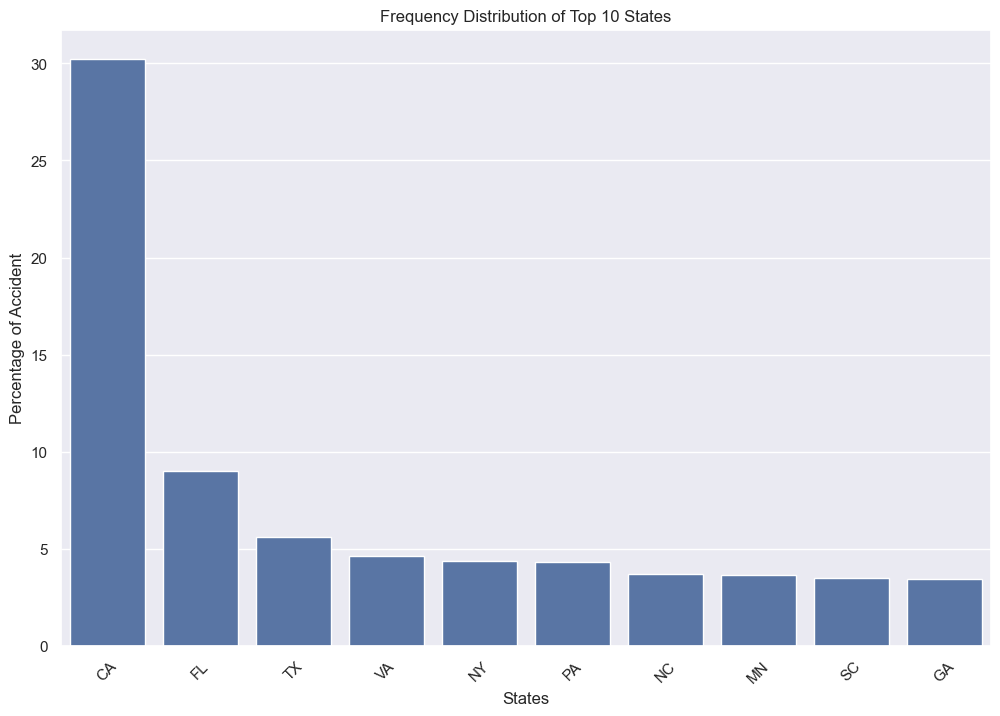

CPU times: total: 125 ms
Wall time: 124 ms


In [11]:
%%time

state_percentage = df['State'].value_counts() * 100/ len(df)
sns.set(style="darkgrid")

# state_count
plt.figure(figsize=(12,8))
sns.barplot(state_percentage.head(10))
plt.title('Frequency Distribution of Top 10 States')

plt.xlabel('States', fontsize=12)
plt.ylabel('Percentage of Accident', fontsize=12)
plt.xticks(rotation = 45)
plt.show()

**Tip:** In Pandas, it's a good practice to typecast categorical features to a category dtype because they make the operations on such columns much faster than the object dtype. You can do the typecasting by using `.astype()` method on your columns as shown below:

In [12]:
example_df = pd.DataFrame({
    'City': ['Dhaka','Chittagong','Khulna','Rajshahi'],
    'Population' : [1.3e6 , 1.2e6 ,1.1e6 ,1e6] 
})

In [13]:
example_df

,City,Population
0,Dhaka,1300000.0
1,Chittagong,1200000.0
2,Khulna,1100000.0
3,Rajshahi,1000000.0


In [14]:
example_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        4 non-null      str    
 1   Population  4 non-null      float64
dtypes: float64(1), str(1)
memory usage: 196.0 bytes


In [15]:
example_df['Population'] = example_df['Population'].astype(int)

In [16]:
example_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   City        4 non-null      str  
 1   Population  4 non-null      int64
dtypes: int64(1), str(1)
memory usage: 196.0 bytes


In [19]:
cat = ['Source', 'Street', 'City', 'County', 'State','Zipcode','Country', 'Timezone', 'Airport_Code','Wind_Direction','Weather_Condition', 'Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']
df[cat] = df[cat].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246629 entries, 0 to 246628
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   ID                     246629 non-null  str     
 1   Source                 246629 non-null  category
 2   Severity               246629 non-null  int64   
 3   Start_Time             246629 non-null  str     
 4   End_Time               246629 non-null  str     
 5   Start_Lat              246629 non-null  float64 
 6   Start_Lng              246629 non-null  float64 
 7   End_Lat                246629 non-null  float64 
 8   End_Lng                246629 non-null  float64 
 9   Distance(mi)           246629 non-null  float64 
 10  Description            246629 non-null  str     
 11  Street                 245859 non-null  category
 12  City                   246627 non-null  category
 13  County                 246629 non-null  category
 14  State                  246629 n

In [7]:
df['Weather_Condition']

0                             NaN
1                             NaN
2                            Fair
3                      Heavy Rain
4                          Cloudy
                   ...           
246624                       Fair
246625                       Rain
246626                       Fair
246627                       Fair
246628    Light Rain with Thunder
Name: Weather_Condition, Length: 246629, dtype: str

In [4]:
df['Weather_Condition'].unique()

[NaN, 'Fair', 'Heavy Rain', 'Cloudy', 'Fog', ..., 'Hail', 'Widespread Dust', 'Heavy Snow with Thunder', 'Rain Shower / Windy', 'Thunder / Wintry Mix / Windy']
Length: 81
Categories (80, str): ['Blowing Dust', 'Blowing Dust / Windy', 'Blowing Snow', 'Blowing Snow / Windy', ..., 'Widespread Dust', 'Widespread Dust / Windy', 'Wintry Mix', 'Wintry Mix / Windy']

## Handling Missing Data/Null Values,  
Handling Missing Data/Null Values is one of the most important data pre-processing steps. It is a huge problem for data analysis because it misshapes our results. It’s difficult to be fully confident in the insights when you know that some entries are missing values.  

Below I have mentioned a few ways to **Handle missing values in Categorical Columns.**  I have used only a few columns of our entire dataframe to understand these methods.

In [5]:
accidents_df = df[['ID', 'Severity', 'Start_Time', 'City', 'State','Source', 'Airport_Code', 'Roundabout', 'Timezone']].copy()

In [6]:
accidents_df.head()

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,NaN,False,US/Eastern
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,NaN,False,US/Eastern
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific


In [22]:
accidents_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246629 entries, 0 to 246628
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   ID            246629 non-null  str     
 1   Severity      246629 non-null  int64   
 2   Start_Time    246629 non-null  str     
 3   City          246627 non-null  category
 4   State         246629 non-null  category
 5   Source        246629 non-null  category
 6   Airport_Code  245753 non-null  category
 7   Roundabout    246629 non-null  bool    
 8   Timezone      246400 non-null  category
dtypes: bool(1), category(5), int64(1), str(2)
memory usage: 7.6 MB


In [24]:
accidents_df.isnull().sum()

ID                0
Severity          0
Start_Time        0
City              2
State             0
Source            0
Airport_Code    876
Roundabout        0
Timezone        229
dtype: int64

In [25]:
accidents_df['City'].nunique()

6644

In [12]:
print("Number of Categories in: ")
cat_cols = ['City','Airport_Code','Timezone']

for cat in cat_cols:
  print(cat, ":", accidents_df[cat].nunique())

Number of Categories in: 
City : 6644
Airport_Code : 1529
Timezone : 4


### 1. Frequent Categorical Imputation:

This is a method in which we **assume** that there is random order of missing values(MAR - Missing at Random) and there's a majority of these missing values.

Under this approach we replace the missing values with the most common class, Hence the first step is to find out which category occurred most in each category using `mode()`.
* [The mode of a set of values is the value that appears most often]

In [13]:
accidents_df['City'].mode()

0    Los Angeles
Name: City, dtype: str

In [14]:
accidents_df['City'].mode()[0]

'Los Angeles'

In [29]:
most_frequent_value = accidents_df['City'].mode()[0]

In [ ]:
accidents_df['City_imputed'] = accidents_df['City'].fillna(most_frequent_value)
# always create a another column rather than modifying the actual column ( returns the imputed column )

In [32]:
accidents_df['City']

0            Newport News
1            Newport News
2                  Dallas
3         Running Springs
4             Los Angeles
               ...       
246624             Dallas
246625       Grand Rapids
246626          Vacaville
246627        Bloomington
246628      Highland Park
Name: City, Length: 246629, dtype: category
Categories (6644, str): ['Abbeville', 'Abbottstown', 'Aberdeen', 'Abernathy', ..., 'Zumbro Falls', 'Zumbrota', 'Zuni', 'Zwingle']

In [15]:
accidents_df.isnull().sum() # no missing value in city imputed

ID                0
Severity          0
Start_Time        0
City              2
State             0
Source            0
Airport_Code    876
Roundabout        0
Timezone        229
dtype: int64

In [16]:
cat_cols = ['City', 'Airport_Code', 'Timezone']

for cat in cat_cols:
    most_frequent_value = accidents_df[cat].mode()[0]
    accidents_df[f'{cat}_imputed'] = accidents_df[cat].fillna(most_frequent_value)

In [35]:
accidents_df.isnull().sum()

ID                        0
Severity                  0
Start_Time                0
City                      2
State                     0
Source                    0
Airport_Code            876
Roundabout                0
Timezone                229
City_imputed              0
Airport_Code_imputed      0
Timezone_imputed          0
dtype: int64

Now you can see that there has been an addition of imputed columns that have zero null values, while the original columns continue to hold those null values which we will drop in our last step.

The Last step is to Drop our original columns and keep the newly imputed ones.

In [37]:
example_df  = pd.DataFrame({
    'City' : ['Dhaka','Chittagong','khulna', 'Rajshahi'],
    'Population' : [ 1.3e6, 1.2e6 ,1.1e6, 1e6]
})

In [38]:
example_df

,City,Population
0,Dhaka,1300000.0
1,Chittagong,1200000.0
2,khulna,1100000.0
3,Rajshahi,1000000.0


In [ ]:
example_df.drop([1,2], axis=0,inplace=True) 
# Inplace directly modfies the original data 

In [41]:
example_df

,City,Population
0,Dhaka,1300000.0
3,Rajshahi,1000000.0


In [17]:
accidents_df = accidents_df.drop(['City','Airport_Code','Timezone'], axis = 1)
# axis= 1 means column , acis = 0 means rows

This is a very simple and one of the most basic approaches to handle missing values in our categorical columns, yet not a preferred one.
* This can distort the relation of the most frequent class and,
* Predictions may become biased due to columns that have max number of null values.

So lets have a look at other ways to do the same and more efficiently.


### 2. Adding a variable to capture NaN:
We use this approach without considering any assumptions, hence can be implemented on all kinds of categorical columns.This will fix the problem of the previous approach.

In this approach, we replace the NAN categories with the most occurred values but in this case, we add a new feature to introduce some weight/importance to the non-imputed and imputed columns. Let's define our dataframe again,

In [18]:
accidents_df = df[['ID', 'Severity', 'Start_Time', 'City', 'State','Source', 'Airport_Code', 'Roundabout', 'Timezone']].copy()

In [19]:
accidents_df['City'].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
246624    False
246625    False
246626    False
246627    False
246628    False
Name: City, Length: 246629, dtype: bool

In [46]:
accidents_df.isna().values

array([[False, False, False, ...,  True, False, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(246629, 9))

In [47]:
cat_cols = ['City','Airport_Code','Timezone']

for cat in cat_cols:
    accidents_df[f'{cat}_imputed'] = accidents_df[cat].isna().values
    
    most_frequent_value = accidents_df[cat].mode()[0]
    accidents_df[f'{cat}'] = accidents_df[cat].fillna(most_frequent_value)

Again this method too has some disadvantages like,
* Creating additional columns can cause Curse of Dimentionality.
* For the Imputed Column to have value, Potentially misunderstood data & the number of missing data should be large enough.

In [48]:
accidents_df

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone,City_imputed,Airport_Code_imputed,Timezone_imputed
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern,False,True,False
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern,False,True,False
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central,False,False,False
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific,False,False,False
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
246624,A-3663193,2,2023-03-31 23:18:00,Dallas,TX,Source1,KADS,False,US/Central,False,False,False
246625,A-3687382,2,2023-03-31 23:19:00,Grand Rapids,MI,Source1,KGRR,False,US/Eastern,False,False,False
246626,A-3660237,2,2023-03-31 23:21:00,Vacaville,CA,Source1,KVCB,False,US/Pacific,False,False,False
246627,A-3678205,2,2023-03-31 23:25:30,Bloomington,CA,Source1,KRAL,False,US/Pacific,False,False,False


### 3. Create a new Category for NAN Values:

Another approach to handling missing values is a very straightforward one. Again this approach can be applied to all categorical columns since we do not consider any assumptions. It has a very simple implementation. We create a new category, lets call it 'the Random Category' for all missing values.

In [26]:
accidents_df = df[['ID', 'Severity', 'Start_Time', 'City', 'State','Source', 'Airport_Code', 'Roundabout', 'Timezone']].copy()

I will replace NAN values with a new name, I have used the name "Unknown" here.

In [ ]:
cat_cols = ['City', 'Airport_Code', 'Timezone']

# First we need to type cast the columns into category before adding the "Unknown" Category 
for cat in cat_cols:
    # Add 'Unknown' to the list of allowed categories
    accidents_df[cat] = accidents_df[cat].cat.add_categories(['Unknown'])
    # Now fill the missing values
    accidents_df[cat] = accidents_df[cat].fillna('Unknown')

In [29]:
accidents_df.head(50)

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,Unknown,False,US/Eastern
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,Unknown,False,US/Eastern
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific
5,A-3741627,4,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
6,A-4246323,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
7,A-3967046,4,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
8,A-3870075,2,2023-01-01 00:01:18,Charlotte,NC,Source1,KCLT,False,US/Eastern
9,A-5010844,2,2023-01-01 00:01:30,San Dimas,CA,Source1,KPOC,False,US/Pacific


In [ ]:
accidents_df.isna().sum() # now we dont have any null value 

ID              0
Severity        0
Start_Time      0
City            0
State           0
Source          0
Airport_Code    0
Roundabout      0
Timezone        0
dtype: int64

This approach preserves the variance of our data. But if the missing data is more, we will land up creating only more random data. Hence this approach doesn't give us good results when there is a high percentage of missing data.

#### Machine learning algorithms and deep learning neural networks require that input and output variables are numbers. This means that categorical data must be encoded into numbers before we can use it to fit and evaluate a model. So another important step while dealing with categorical data is to encode our classes.  


# Encoding categorical data:

I'll continue to work with a small part of the entire data frame to understand these encoding techniques. I'll use the 2nd technique I mentioned to handle null values from it first and let us see what our final dataframe looks like.

In [20]:
cat = ['Source', 'Street', 'City', 'County', 'State','Zipcode','Country', 'Timezone', 'Airport_Code','Wind_Direction','Weather_Condition', 'Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']
df[cat] = df[cat].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246629 entries, 0 to 246628
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   ID                     246629 non-null  str     
 1   Source                 246629 non-null  category
 2   Severity               246629 non-null  int64   
 3   Start_Time             246629 non-null  str     
 4   End_Time               246629 non-null  str     
 5   Start_Lat              246629 non-null  float64 
 6   Start_Lng              246629 non-null  float64 
 7   End_Lat                246629 non-null  float64 
 8   End_Lng                246629 non-null  float64 
 9   Distance(mi)           246629 non-null  float64 
 10  Description            246629 non-null  str     
 11  Street                 245859 non-null  category
 12  City                   246627 non-null  category
 13  County                 246629 non-null  category
 14  State                  246629 n

In [21]:
accidents_df = df[['ID', 'Severity', 'Start_Time', 'City', 'State','Source', 'Airport_Code', 'Roundabout', 'Timezone']].copy()

In [28]:
cat_cols = ['City', 'Airport_Code', 'Timezone']

for cat in cat_cols:
    most_frequent_value = accidents_df[cat].mode()[0]
    accidents_df[f'{cat}'] = accidents_df[cat].fillna(most_frequent_value)

In [23]:
accidents_df

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific
...,...,...,...,...,...,...,...,...,...
246624,A-3663193,2,2023-03-31 23:18:00,Dallas,TX,Source1,KADS,False,US/Central
246625,A-3687382,2,2023-03-31 23:19:00,Grand Rapids,MI,Source1,KGRR,False,US/Eastern
246626,A-3660237,2,2023-03-31 23:21:00,Vacaville,CA,Source1,KVCB,False,US/Pacific
246627,A-3678205,2,2023-03-31 23:25:30,Bloomington,CA,Source1,KRAL,False,US/Pacific


In [24]:
accidents_df['Timezone'].unique()

['US/Eastern', 'US/Central', 'US/Pacific', 'US/Mountain']
Categories (4, str): ['US/Central', 'US/Eastern', 'US/Mountain', 'US/Pacific']

In [25]:
replace_map = {'Timezone' : {
                            'US/Eastern':1,
                            'US/Central':2, 
                            'US/Pacific':3,
                            'US/Mountain':4
                           } 
               }

Pandas dataframe.replace() function is used to replace a string, regex, list, dictionary, series, number, etc. from a Pandas Dataframe in Python. Every instance of the provided value is replaced after a thorough search of the full DataFrame.

In [32]:
accidents_df_replace = accidents_df.copy()
tz_map = replace_map["Timezone"]
accidents_df_replace["Timezone"] = (
    accidents_df_replace["Timezone"]
    .astype("string")
    .map(tz_map)
    .astype("Int64")
)

In [33]:
accidents_df_replace.sample(5)

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
9655,A-4324427,2,2023-01-03 06:45:47,Saint Louis,MO,Source1,KCPS,False,2
138871,A-4803525,2,2023-01-28 12:37:24,Columbia,SC,Source1,KCUB,False,1
118901,A-3779699,2,2023-01-25 17:01:54,Rochester,NY,Source1,KROC,False,1
114200,A-5365322,2,2023-01-25 08:26:00,Phoenix,AZ,Source1,KSDL,False,4
219976,A-3659425,2,2023-03-20 16:08:00,Bakersfield,CA,Source1,KBFL,False,3


You can see the `Timezone` column encoded as the mapped numbers in the dataframe above.

### 2. Label Encoding:

Another approach to encode categorical data is to convert each value in the column into a number. We use this encoding technique when the categorical feature is ordinal, i.e like I mentioned above, ordered categories. Hence encoding should reflect the sequence.

In Label encoding, each label is converted into an integer value and these integers are always between 0 and num_categories-1.
One way of achieving this is by using pandas `cat.codes` on our categorical column.


In [34]:
accidents_df_lc = accidents_df.copy()

In [35]:
accidents_df_lc['Timezone'].unique()

['US/Eastern', 'US/Central', 'US/Pacific', 'US/Mountain']
Categories (4, str): ['US/Central', 'US/Eastern', 'US/Mountain', 'US/Pacific']

In [36]:
accidents_df_lc.head(5)

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific


In [38]:
accidents_df_lc['Timezone'].unique()

['US/Eastern', 'US/Central', 'US/Pacific', 'US/Mountain']
Categories (4, str): ['US/Central', 'US/Eastern', 'US/Mountain', 'US/Pacific']

In [ ]:
accidents_df_lc['Timezone'].cat.codes
# the indexing came from the unique method
# cat only works with categorical datatype column

0         1
1         1
2         0
3         3
4         3
         ..
246624    0
246625    1
246626    3
246627    3
246628    1
Length: 246629, dtype: int8

In [39]:
accidents_df_lc['Timezone'] = accidents_df_lc['Timezone'].cat.codes

In [40]:
accidents_df_lc.head(5)

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,1
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,1
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,0
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,3
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,3


In [41]:
accidents_df_lc['Timezone'].unique()

array([1, 0, 3, 2], dtype=int8)

### 3. One Hot Encoding:

This encoding technique is used when the features are nominal i.e do not have any order. For example in this dataset, the column `Airport_Codes` is categorical but we cant arrange them in a sequence.

In one hot encoding, for each level of a categorical feature, we create a new variable. In simple terms, each category is converted into a new column. Then, each category is mapped with a binary variable containing either 0 or 1, where 0 represents the absence and 1 represents the presence of that category.
These newly created binary features/columns are called **Dummy Variables** and are = no. of categories in a column.

The simplest way to use this encoding tactic is by using `pandas` `.get_dummies()` method.  This function takes 3 arguments: dataframe, columns to perform encoding on, and lastly, the `prefix` argument that will allow us to specify the prefix for the new columns that will be created.



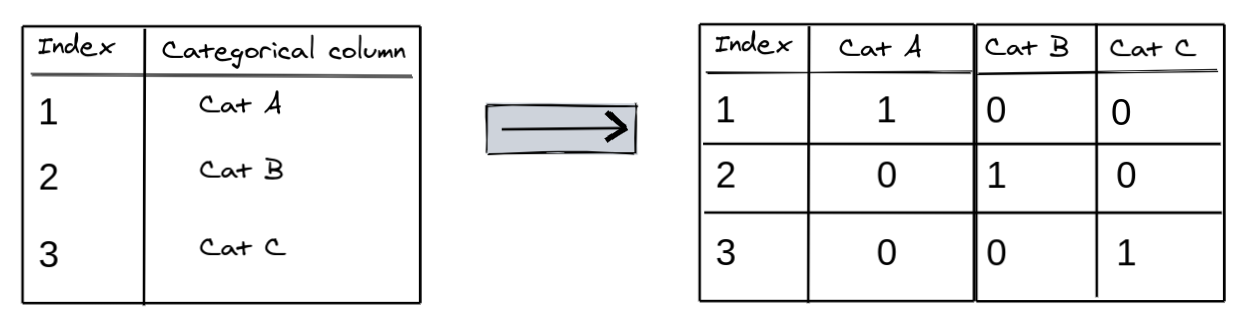

In [43]:
accidents_df_one_hot = accidents_df.copy()

In [44]:
accidents_df_one_hot = pd.get_dummies(accidents_df_one_hot , columns=['Timezone'], prefix= ['Timezone'])

In [45]:
accidents_df_one_hot.head(5)

,ID,Severity,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone_US/Central,Timezone_US/Eastern,Timezone_US/Mountain,Timezone_US/Pacific
0,A-4955077,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,False,True,False,False
1,A-4952107,2,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,False,True,False,False
2,A-3845732,2,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,True,False,False,False
3,A-4478492,2,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,False,False,False,True
4,A-4888265,2,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,False,False,False,True


In [46]:
accidents_df_one_hot = accidents_df.copy()

accidents_df_one_hot = pd.get_dummies(accidents_df_one_hot, columns=['Severity'], prefix = ['Severity'])

In [47]:
accidents_df_one_hot.head(5)

,ID,Start_Time,City,State,Source,Airport_Code,Roundabout,Timezone,Severity_2,Severity_4
0,A-4955077,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern,True,False
1,A-4952107,2023-01-01 00:00:34,Newport News,VA,Source1,KCQT,False,US/Eastern,True,False
2,A-3845732,2023-01-01 00:00:41,Dallas,TX,Source1,KDAL,False,US/Central,True,False
3,A-4478492,2023-01-01 00:01:00,Running Springs,CA,Source1,KSBD,False,US/Pacific,True,False
4,A-4888265,2023-01-01 00:01:00,Los Angeles,CA,Source1,KSMO,False,US/Pacific,True,False
